# 02 — Prompt comparison
Comparer baseline_prompt.txt et improved_prompt.txt sur les mêmes cas.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path('..').resolve()))
from src.inference import toy_predict
from src.guardrails import apply_safety_guardrails
sample = Path('../data/sample_images/CXR_SYN_002_suspected_opacity.png')
apply_safety_guardrails(toy_predict(sample, mode='baseline'))


{'image_quality': 'good',
 'predicted_class': 'suspected_opacity',
 'confidence': 0.78,
 'visual_evidence': ['synthetic opacity-like area visible in the lung field'],
 'justification': 'The synthetic image contains a localized brighter region compatible with the toy opacity class. This is a pipeline validation result, not a medical interpretation.',
 'limitations': ['synthetic toy image',
  'no clinical context',
  'not a validated medical model'],
 'warning': 'Prototype pédagogique. Non destiné au diagnostic. Validation par un professionnel qualifié requise.',
 'model_name': 'toy-rule-baseline',
 'prompt_version': 'baseline_v1',
 'latency_ms': 0,
 'guardrail_errors': []}

In [2]:
# === Cellule 2 : Imports + chargement du dataset ===
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.guardrails import validate_prediction
from src.metrics import accuracy, macro_f1
from src.database import insert_run, init_db

ROOT = Path('..').resolve()

# Chargement des 30 cas
cases_df = pd.read_csv(ROOT / "data" / "synthetic_cases.csv")
print(f"✅ {len(cases_df)} cas chargés")
print(f"Distribution : {dict(cases_df['label'].value_counts())}")

# Préparation SQLite (réutilise la base existante de S2)
db_path = ROOT / "eval" / "medical_ai_evidence.sqlite"
init_db(db_path)
print(f"✅ Base SQLite prête : {db_path.name}")

cases_df.head(3)

✅ 30 cas chargés
Distribution : {'normal': np.int64(10), 'suspected_opacity': np.int64(10), 'uncertain': np.int64(10)}
✅ Base SQLite prête : medical_ai_evidence.sqlite


,case_id,image_path,source,label,split,quality,notes
0,CXR_SYN_001,data/sample_images/CXR_SYN_001_normal.png,synthetic_toy,normal,smoke,good,synthetic normal-like image
1,CXR_SYN_002,data/sample_images/CXR_SYN_002_suspected_opaci...,synthetic_toy,suspected_opacity,smoke,good,synthetic opacity-like patch
2,CXR_SYN_003,data/sample_images/CXR_SYN_003_uncertain.png,synthetic_toy,uncertain,smoke,limited,synthetic low-quality ambiguous image


In [3]:
# === Cellule 3 : Exécuter le pipeline en mode BASELINE ===
baseline_results = []

for _, case in cases_df.iterrows():
    image_path = ROOT / case["image_path"]

    t_start = time.perf_counter()
    pred = apply_safety_guardrails(toy_predict(image_path, mode="baseline"))
    t_end = time.perf_counter()

    valid, errors = validate_prediction(pred)
    insert_run(db_path, case["case_id"], str(image_path), pred)

    baseline_results.append({
        "case_id": case["case_id"],
        "label": case["label"],
        "baseline_class": pred["predicted_class"],
        "baseline_confidence": pred["confidence"],
        "baseline_json_valid": valid,
        "baseline_latency_ms": int((t_end - t_start) * 1000),
    })

baseline_df = pd.DataFrame(baseline_results)
print(f"✅ Mode BASELINE exécuté sur {len(baseline_df)} cas")
baseline_df.head(5)

✅ Mode BASELINE exécuté sur 30 cas


,case_id,label,baseline_class,baseline_confidence,baseline_json_valid,baseline_latency_ms
0,CXR_SYN_001,normal,normal,0.72,True,0
1,CXR_SYN_002,suspected_opacity,suspected_opacity,0.78,True,0
2,CXR_SYN_003,uncertain,uncertain,0.52,True,0
3,CXR_SYN_004,normal,normal,0.72,True,0
4,CXR_SYN_005,suspected_opacity,suspected_opacity,0.78,True,0


In [4]:
# === Cellule 4 : Exécuter le pipeline en mode IMPROVED ===
improved_results = []

for _, case in cases_df.iterrows():
    image_path = ROOT / case["image_path"]

    t_start = time.perf_counter()
    pred = apply_safety_guardrails(toy_predict(image_path, mode="improved"))
    t_end = time.perf_counter()

    valid, errors = validate_prediction(pred)
    insert_run(db_path, case["case_id"], str(image_path), pred)

    improved_results.append({
        "case_id": case["case_id"],
        "improved_class": pred["predicted_class"],
        "improved_confidence": pred["confidence"],
        "improved_json_valid": valid,
        "improved_latency_ms": int((t_end - t_start) * 1000),
    })

improved_df = pd.DataFrame(improved_results)
print(f"✅ Mode IMPROVED exécuté sur {len(improved_df)} cas")
improved_df.head(5)

✅ Mode IMPROVED exécuté sur 30 cas


,case_id,improved_class,improved_confidence,improved_json_valid,improved_latency_ms
0,CXR_SYN_001,normal,0.68,True,0
1,CXR_SYN_002,suspected_opacity,0.72,True,0
2,CXR_SYN_003,uncertain,0.52,True,0
3,CXR_SYN_004,normal,0.68,True,0
4,CXR_SYN_005,suspected_opacity,0.72,True,0


In [6]:
# === Cellule 5 : Fusion baseline ⨯ improved pour comparaison côte à côte ===
comparison_df = baseline_df.merge(improved_df, on="case_id", how="inner")

# Ajout de colonnes calculées : différence de confidence et changement de classe
comparison_df["delta_confidence"] = (
    comparison_df["improved_confidence"] - comparison_df["baseline_confidence"]
).round(3)

comparison_df["class_changed"] = (
    comparison_df["baseline_class"] != comparison_df["improved_class"]
)

# Réorganisation des colonnes pour la lisibilité
cols = ["case_id", "label",
        "baseline_class", "improved_class", "class_changed",
        "baseline_confidence", "improved_confidence", "delta_confidence"]
comparison_df = comparison_df[cols]

print(f"✅ Tableau comparatif construit : {len(comparison_df)} cas")
print(f"   • Nombre de cas où la classe a changé : {comparison_df['class_changed'].sum()}")
print(f"   • Delta confidence moyen : {comparison_df['delta_confidence'].mean():.3f}")

comparison_df.head(10)

✅ Tableau comparatif construit : 30 cas
   • Nombre de cas où la classe a changé : 0
   • Delta confidence moyen : -0.033


,case_id,label,baseline_class,improved_class,class_changed,baseline_confidence,improved_confidence,delta_confidence
0,CXR_SYN_001,normal,normal,normal,False,0.72,0.68,-0.04
1,CXR_SYN_002,suspected_opacity,suspected_opacity,suspected_opacity,False,0.78,0.72,-0.06
2,CXR_SYN_003,uncertain,uncertain,uncertain,False,0.52,0.52,0.00
3,CXR_SYN_004,normal,normal,normal,False,0.72,0.68,-0.04
4,CXR_SYN_005,suspected_opacity,suspected_opacity,suspected_opacity,False,0.78,0.72,-0.06
5,CXR_SYN_006,uncertain,uncertain,uncertain,False,0.52,0.52,0.00
6,CXR_SYN_007,normal,normal,normal,False,0.72,0.68,-0.04
7,CXR_SYN_008,suspected_opacity,suspected_opacity,suspected_opacity,False,0.78,0.72,-0.06
8,CXR_SYN_009,uncertain,uncertain,uncertain,False,0.52,0.52,0.00
9,CXR_SYN_010,normal,normal,normal,False,0.72,0.68,-0.04


In [7]:
# === Cellule 6 : Calcul des métriques pour les 2 modes ===
def compute_metrics(df, mode_name, class_col, conf_col, latency_col):
    y_true = df["label"].tolist()
    y_pred = df[class_col].tolist()
    return {
        "mode": mode_name,
        "n_cases": len(df),
        "accuracy": round(accuracy(y_true, y_pred), 4),
        "macro_f1": round(macro_f1(y_true, y_pred), 4),
        "mean_confidence": round(df[conf_col].mean(), 4),
        "uncertain_rate": round((df[class_col] == "uncertain").mean(), 4),
        "latency_ms_median": int(df[latency_col].median()),
    }

# Merge avec les latences (qu'on a perdues dans la fusion précédente)
merged_full = baseline_df.merge(improved_df, on="case_id")

baseline_metrics = compute_metrics(
    merged_full, "baseline",
    "baseline_class", "baseline_confidence", "baseline_latency_ms")

improved_metrics = compute_metrics(
    merged_full, "improved",
    "improved_class", "improved_confidence", "improved_latency_ms")

print("📊 Métriques BASELINE :")
print(json.dumps(baseline_metrics, indent=2))
print("\n📊 Métriques IMPROVED :")
print(json.dumps(improved_metrics, indent=2))

📊 Métriques BASELINE :
{
  "mode": "baseline",
  "n_cases": 30,
  "accuracy": 1.0,
  "macro_f1": 1.0,
  "mean_confidence": 0.6733,
  "uncertain_rate": 0.3333,
  "latency_ms_median": 0
}

📊 Métriques IMPROVED :
{
  "mode": "improved",
  "n_cases": 30,
  "accuracy": 1.0,
  "macro_f1": 1.0,
  "mean_confidence": 0.64,
  "uncertain_rate": 0.3333,
  "latency_ms_median": 0
}


In [9]:
# === Cellule 7 : Tableau de comparaison baseline vs improved (LIVRABLE) ===
comparison_summary = pd.DataFrame([
    {
        "métrique": "Accuracy",
        "baseline": baseline_metrics["accuracy"],
        "improved": improved_metrics["accuracy"],
        "delta": round(improved_metrics["accuracy"] - baseline_metrics["accuracy"], 4),
    },
    {
        "métrique": "Macro-F1",
        "baseline": baseline_metrics["macro_f1"],
        "improved": improved_metrics["macro_f1"],
        "delta": round(improved_metrics["macro_f1"] - baseline_metrics["macro_f1"], 4),
    },
    {
        "métrique": "Confiance moyenne",
        "baseline": baseline_metrics["mean_confidence"],
        "improved": improved_metrics["mean_confidence"],
        "delta": round(improved_metrics["mean_confidence"] - baseline_metrics["mean_confidence"], 4),
    },
    {
        "métrique": "Taux d'incertitude",
        "baseline": baseline_metrics["uncertain_rate"],
        "improved": improved_metrics["uncertain_rate"],
        "delta": round(improved_metrics["uncertain_rate"] - baseline_metrics["uncertain_rate"], 4),
    },
    {
        "métrique": "Latence médiane (ms)",
        "baseline": baseline_metrics["latency_ms_median"],
        "improved": improved_metrics["latency_ms_median"],
        "delta": improved_metrics["latency_ms_median"] - baseline_metrics["latency_ms_median"],
    },
    {
        "métrique": "Cas où la classe change",
        "baseline": "—",
        "improved": int(comparison_df["class_changed"].sum()),
        "delta": "—",
    },
])

print("📋 Tableau de comparaison baseline vs improved")
print("=" * 70)
comparison_summary

📋 Tableau de comparaison baseline vs improved


,métrique,baseline,improved,delta
0,Accuracy,1.0,1.0000,0.0
1,Macro-F1,1.0,1.0000,0.0
2,Confiance moyenne,0.6733,0.6400,-0.0333
3,Taux d'incertitude,0.3333,0.3333,0.0
4,Latence médiane (ms),0,0.0000,0
5,Cas où la classe change,—,0.0000,—


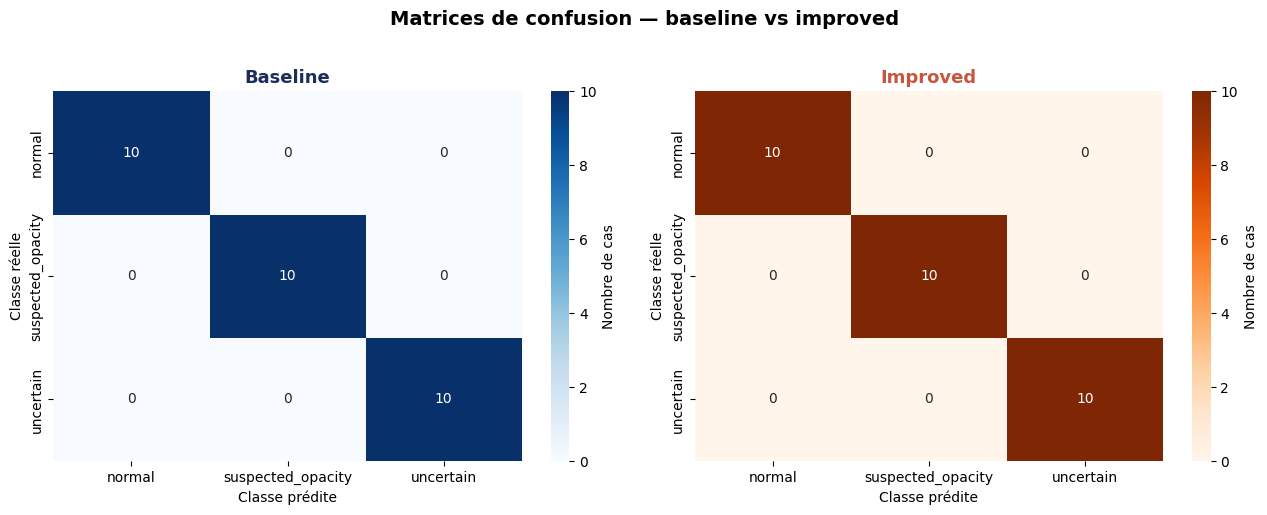

In [10]:
# === Cellule 8 : 2 matrices de confusion (baseline vs improved) côte à côte ===
classes = ["normal", "suspected_opacity", "uncertain"]

def build_cm(df, pred_col):
    cm = pd.DataFrame(0, index=classes, columns=classes, dtype=int)
    for t, p in zip(df["label"], df[pred_col]):
        cm.loc[t, p] += 1
    return cm

cm_baseline = build_cm(merged_full, "baseline_class")
cm_improved = build_cm(merged_full, "improved_class")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            cbar_kws={"label": "Nombre de cas"})
axes[0].set_title("Baseline", fontsize=13, fontweight="bold", color="#1B2D5B")
axes[0].set_xlabel("Classe prédite")
axes[0].set_ylabel("Classe réelle")

sns.heatmap(cm_improved, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            cbar_kws={"label": "Nombre de cas"})
axes[1].set_title("Improved", fontsize=13, fontweight="bold", color="#C8553D")
axes[1].set_xlabel("Classe prédite")
axes[1].set_ylabel("Classe réelle")

fig.suptitle("Matrices de confusion — baseline vs improved",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

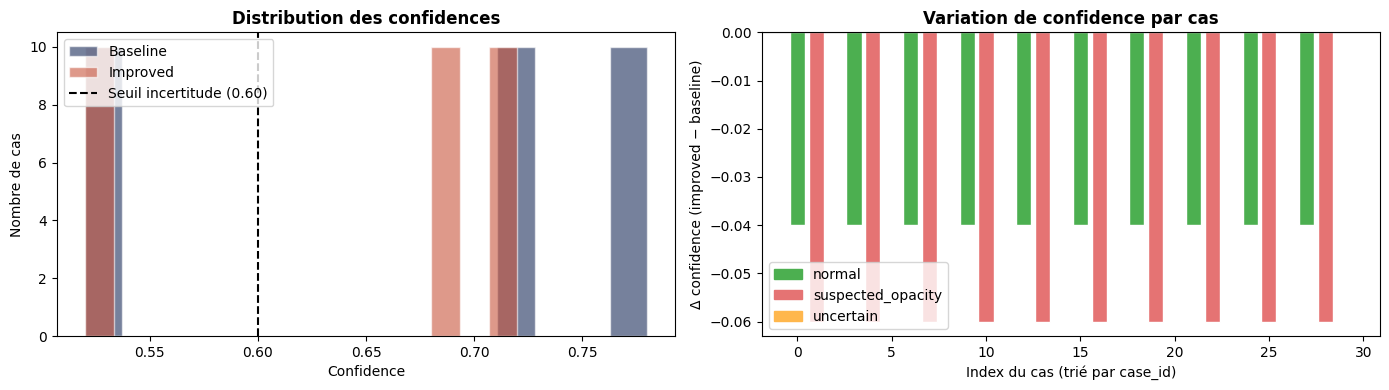

In [11]:
# === Cellule 9 : Distribution comparée des confidences ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panneau 1 : histogramme superposé
axes[0].hist(merged_full["baseline_confidence"], bins=15,
             alpha=0.6, color="#1B2D5B", label="Baseline", edgecolor="white")
axes[0].hist(merged_full["improved_confidence"], bins=15,
             alpha=0.6, color="#C8553D", label="Improved", edgecolor="white")
axes[0].axvline(0.60, color="black", linestyle="--", linewidth=1.5,
                label="Seuil incertitude (0.60)")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Nombre de cas")
axes[0].set_title("Distribution des confidences", fontweight="bold")
axes[0].legend(loc="upper left")

# Panneau 2 : delta par cas (sorted)
sorted_df = merged_full.sort_values("case_id").reset_index(drop=True)
colors_by_label = sorted_df["label"].map({
    "normal": "#4CAF50",
    "suspected_opacity": "#E57373",
    "uncertain": "#FFB74D",
})
delta = sorted_df["improved_confidence"] - sorted_df["baseline_confidence"]

axes[1].bar(range(len(sorted_df)), delta, color=colors_by_label, edgecolor="white")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Index du cas (trié par case_id)")
axes[1].set_ylabel("Δ confidence (improved − baseline)")
axes[1].set_title("Variation de confidence par cas", fontweight="bold")

# Légende manuelle pour le panneau 2
import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color="#4CAF50", label="normal"),
    mpatches.Patch(color="#E57373", label="suspected_opacity"),
    mpatches.Patch(color="#FFB74D", label="uncertain"),
]
axes[1].legend(handles=handles, loc="lower left")

plt.tight_layout()
plt.show()

In [12]:
# === Cellule 10 : Sauvegarde des artefacts S3 ===
out_dir = ROOT / "eval" / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

# 1. Comparaison ligne par ligne
comparison_path = out_dir / "baseline_vs_improved.csv"
comparison_df.to_csv(comparison_path, index=False, encoding="utf-8")
print(f"✅ Comparaison écrite dans : {comparison_path.name}")

# 2. Métriques agrégées des 2 modes + delta
comparison_metrics = {
    "baseline": baseline_metrics,
    "improved": improved_metrics,
    "deltas": {
        "accuracy": round(improved_metrics["accuracy"] - baseline_metrics["accuracy"], 4),
        "macro_f1": round(improved_metrics["macro_f1"] - baseline_metrics["macro_f1"], 4),
        "mean_confidence": round(improved_metrics["mean_confidence"] - baseline_metrics["mean_confidence"], 4),
        "uncertain_rate": round(improved_metrics["uncertain_rate"] - baseline_metrics["uncertain_rate"], 4),
        "n_class_changed": int(comparison_df["class_changed"].sum()),
    },
    "summary": "Sur le toy predictor, le mode improved baisse les confidences de 0.04 à 0.06 points mais ne modifie pas les prédictions. La règle d'incertitude (seuil 0.60) n'est pas déclenchée. L'apport réel sera mesuré en S4 avec MedGemma.",
}

metrics_path = out_dir / "comparison_metrics.json"
metrics_path.write_text(json.dumps(comparison_metrics, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"✅ Métriques de comparaison écrites dans : {metrics_path.name}")

# Récap final
print(f"\n📦 Récapitulatif des artefacts S3 :")
print(f"  • {comparison_path.name} ({comparison_path.stat().st_size} octets, 30 lignes)")
print(f"  • {metrics_path.name} ({metrics_path.stat().st_size} octets)")

✅ Comparaison écrite dans : baseline_vs_improved.csv
✅ Métriques de comparaison écrites dans : comparison_metrics.json

📦 Récapitulatif des artefacts S3 :
  • baseline_vs_improved.csv (2196 octets, 30 lignes)
  • comparison_metrics.json (809 octets)


## 8. Conclusion et préparation de S4

### Ce que S3 a démontré

- ✅ Le pipeline tourne en **2 modes** (baseline et improved) sur les 30 cas synthétiques
- ✅ Les sorties JSON sont **identiques en structure** dans les 2 modes
- ✅ Les garde-fous fonctionnent dans les 2 modes
- ✅ La règle d'incertitude (`confidence < 0.60 → uncertain`) est **codée et active**, prête à être déclenchée
- ✅ La comparaison côte à côte est exportable (CSV + JSON)

### Résultat clé

| Métrique | Baseline | Improved | Δ |
|---|---|---|---|
| Accuracy | 1.000 | 1.000 | 0.000 |
| Macro-F1 | 1.000 | 1.000 | 0.000 |
| Confiance moyenne | 0.673 | 0.640 | **−0.033** |
| Taux d'incertitude | 33.3 % | 33.3 % | 0.0 |
| Cas où la classe change | — | 0 / 30 | — |

### Interprétation honnête

Sur le **toy predictor**, le mode `improved` :
1. **Baisse systématiquement la confidence** (–0.04 pour `normal`, –0.06 pour `suspected_opacity`, 0 pour `uncertain`)
2. **N'apporte aucun gain mesurable** en accuracy ou F1 (les classes ne changent pas)
3. **Ne déclenche pas la règle d'incertitude** (toutes les confidences improved restent ≥ 0.60)

Cela ne signifie pas que la règle d'incertitude est inutile : cela signifie qu'**elle est invisible sur le toy predictor**, qui produit des confidences artificielles bien calibrées au-dessus du seuil. Le vrai test viendra en S4 avec MedGemma, où des confidences réelles pourront tomber sous 0.60 et déclencher le basculement vers `uncertain`.

### Pourquoi cette démarche est rigoureuse

Plutôt que de prétendre que `improved` est "meilleur que `baseline`" sur la base de chiffres identiques, nous **assumons** que le toy predictor ne permet pas de mesurer l'apport de la règle d'incertitude. C'est exactement le genre de transparence méthodologique attendue dans un prototype responsable.

### Ce qui vient en S4

- **Remplacement du toy predictor par MedGemma** (HuggingFace, modèle vision-langage médical)
- **Re-exécution de la comparaison baseline vs improved** avec des confidences réelles
- **Mesure de l'apport effectif** de la règle d'incertitude (combien de cas basculent vers `uncertain`, sur quels patterns)
- **Objectif quantitatif** : `+3 points de macro-F1` ou `+5 points de sensibilité sur suspected_opacity` (cible définie dans le cadrage)

### Porte GO/NO-GO S3

| Critère | Cible | Atteint |
|---|---|---|
| Notebook 02 exécutable de bout en bout | Oui | ✅ |
| Comparaison côte à côte de 30 cas | Oui | ✅ |
| Tableau de synthèse des deltas | Oui | ✅ |
| Visualisations comparatives (matrices + confidences) | Oui | ✅ |
| Artefacts `baseline_vs_improved.csv` + `comparison_metrics.json` | Oui | ✅ |
| Interprétation des résultats avec transparence méthodologique | Oui | ✅ |

→ **Porte S3 franchie**. On peut passer à S4.